# La Gomera Weekly Audit + EDA Template

**Project:** Climate–Mortality

**Goal:**  QA → temperature → calima → interaction → short narrative close.


## 0. Setup



In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- island parameters: edit these four values ----
ISLAND_NAME = "gomera"
ISLAND_CODE = "gom"
ISLAND_SLUG = "gomera"   # used in data/processed/<slug>/...
REPORT_CODE = "gom"           # used in reports/<code>/
FIG_SLUG = "gomera"      # used in reports/figures/islas/<slug>/eda
MASTER_FILENAME = "master_gom_2015_2024.parquet"
CALIMA_FILENAME = "calima_proxy_weekly_gom_2015_2024_v2.parquet"

CWD = Path.cwd().resolve()

# If running from islands/<island>, go up two levels to repo root
if CWD.name == ISLAND_NAME and CWD.parent.name == "islands":
    ROOT = CWD.parent.parent
else:
    ROOT = CWD

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("CWD :", CWD)
print("ROOT:", ROOT)
print("src exists?:", (ROOT / "src").exists())

# --- shared notebook helpers ---
from src.utils.d25_nb_utils import (
    section, glance, checks, missing_table, num_summary, set_island_paths,
    autosave_fig, save_table,
)

# --- reports output paths ---
REPORTS_DIR = ROOT / "reports" / "islands"
FIG_DIR = REPORTS_DIR / "figures" / ISLAND_NAME
TAB_DIR = REPORTS_DIR / "tables" / ISLAND_NAME

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

# --- data input ---
FP = ROOT / "data/processed" / ISLAND_NAME / "master" / f"master_{ISLAND_CODE}_2015_2024.parquet"
print("FP:", FP)

assert FP.exists(), f"Missing file: {FP}"

CWD : C:\dev\projects\climate_mortality\islands\gomera
ROOT: C:\dev\projects\climate_mortality
src exists?: True
FIG_DIR: C:\dev\projects\climate_mortality\reports\islands\figures\gomera
TAB_DIR: C:\dev\projects\climate_mortality\reports\islands\tables\gomera
FP: C:\dev\projects\climate_mortality\data\processed\gomera\master\master_gom_2015_2024.parquet


## 1. Load data
Load the island master dataset and subset to the chosen island code if needed.


In [2]:
section(f"EDA core weekly {ISLAND_NAME}")

df = pd.read_parquet(FP)
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

if "island_code" in df.columns:
    df = df.loc[df["island_code"].eq(ISLAND_CODE)].copy()

glance(df, label=f"eda_core_weekly_{ISLAND_CODE}", n=5)
display(checks(df, required=["week_start", "deaths_week"], key=["week_start"], dt="week_start"))
display(num_summary(df))



EDA core weekly gomera

--- eda_core_weekly_gom ---
shape: (471, 38)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
deaths_missing_week                     int64
temp_c_mean                           float64
tmax_c_mean                           float64
tmin_c_mean                           float64
humidity_mean                         float64
pressure_hpa_mean                     float64
wind_ms_mean                          float64
low_vis_confirmed_days_week           float64
low_vis_confirmed_any_week            float64
low_vis_possible_days_week            float64
low_vis_possible_any_week             float64
low_vis_any_days_week                 float64
low_vis_any_week                      float64
confirmed_airports_max_week           float64
possible_airports_max_week            float64


,week_start,year,island,island_code,deaths_week,deaths_missing_week,temp_c_mean,tmax_c_mean,tmin_c_mean,humidity_mean,...,O3,days_with_pm10,days_missing_pm10,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag,calima_level_week
0,2015-12-28,2015,gomera,gom,4.0,0,19.050000,23.150000,15.000000,68.666667,...,67.333333,3,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,2016-01-04,2016,gomera,gom,5.0,0,19.185714,22.085714,16.285714,71.571429,...,71.285714,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,2016-01-11,2016,gomera,gom,3.0,0,21.271429,24.585714,17.971429,64.428571,...,59.571429,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,2016-01-18,2016,gomera,gom,7.0,0,19.814286,23.242857,16.428571,71.000000,...,71.428571,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,2016-01-25,2016,gomera,gom,5.0,0,20.685714,24.114286,17.242857,62.285714,...,80.000000,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0


,name,ok,detail
0,required_cols_present,True,ok
1,datetime_parse_week_start,True,bad=0
2,duplicates_on_key,True,dups=0
3,total_missing_cells,True,missing_cells=1522
4,deaths_nonnegative,True,neg=0


,count,mean,std,min,25%,50%,75%,max
year,471.0,2019.993631,2.594996,2015.000000,2018.000000,2020.000000,2022.000000,2024.000000
deaths_week,453.0,4.086093,1.984253,0.000000,3.000000,4.000000,5.000000,10.000000
deaths_missing_week,471.0,0.038217,0.191923,0.000000,0.000000,0.000000,0.000000,1.000000
temp_c_mean,471.0,22.242165,2.596918,17.071429,20.035714,21.942857,24.492857,29.600000
tmax_c_mean,471.0,24.974366,2.733014,19.285714,22.771429,24.671429,26.953571,34.100000
tmin_c_mean,471.0,19.511005,2.570053,14.485714,17.278571,19.400000,21.942857,25.514286
humidity_mean,471.0,69.651198,7.481251,33.000000,65.571429,70.285714,74.714286,87.285714
pressure_hpa_mean,471.0,1015.415745,5.321793,989.250000,1014.042857,1015.750000,1017.696429,1025.464286
wind_ms_mean,470.0,3.411778,0.986528,0.000000,2.675000,3.307143,4.114286,6.157143
low_vis_confirmed_days_week,460.0,0.182609,0.533539,0.000000,0.000000,0.000000,0.000000,4.000000


In [3]:
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df["month"] = df["week_start"].dt.month
df = df.sort_values("week_start").reset_index(drop=True)

if "tmax_anom_mean" not in df.columns and "tmax_c_mean" in df.columns:
    monthly_ref = df.groupby("month")["tmax_c_mean"].transform("mean")
    df["tmax_anom_mean"] = df["tmax_c_mean"] - monthly_ref
    print("Created tmax_anom_mean from tmax_c_mean using month-of-year mean.")
else:
    print("tmax_anom_mean already present.")

if "excess_deaths" not in df.columns and "deaths_week" in df.columns:
    deaths_ref = df.groupby("month")["deaths_week"].transform("mean")
    df["excess_deaths"] = df["deaths_week"] - deaths_ref
    print("Created excess_deaths from deaths_week using month-of-year mean.")
else:
    print("excess_deaths already present or deaths_week missing.")

calima_fp = ROOT / "data" / "processed" / ISLAND_SLUG / "calima" / CALIMA_FILENAME
print("Calima proxy FP:", calima_fp)

if calima_fp.exists():
    calima = pd.read_parquet(calima_fp).copy()
    calima["week_start"] = pd.to_datetime(calima["week_start"], errors="coerce")

    keep = ["week_start", "calima_proxy_score_v2", "calima_proxy_level_v2"]
    extra_keep = [c for c in ["cap_dust_yellow_plus_week", "cap_dust_level_max_week", "calima_dai_flag"] if c in calima.columns]
    calima_keep = [c for c in keep + extra_keep if c in calima.columns]

    overlap = [c for c in calima_keep if c != "week_start" and c in df.columns]
    if overlap:
        df = df.drop(columns=overlap)

    df = df.merge(calima[calima_keep], on="week_start", how="left")
    print("Merged calima proxy columns:", [c for c in calima_keep if c != "week_start"])
else:
    print("Calima proxy weekly dataset not found. Section 6.1 will be skipped.")


Created tmax_anom_mean from tmax_c_mean using month-of-year mean.
Created excess_deaths from deaths_week using month-of-year mean.
Calima proxy FP: C:\dev\projects\climate_mortality\data\processed\gomera\calima\calima_proxy_weekly_gom_2015_2024_v2.parquet
Merged calima proxy columns: ['calima_proxy_score_v2', 'calima_proxy_level_v2', 'cap_dust_yellow_plus_week', 'cap_dust_level_max_week', 'calima_dai_flag']


## 2. QA / Audit
Minimal checks to confirm weekly uniqueness, required columns, and coverage.


In [4]:
qa = checks(df, required=["week_start", "deaths_week"], key=["week_start"], dt="week_start")
display(qa)

miss = missing_table(df)
display(miss.head(25))

save_table(qa, TAB_DIR, f"qa_checks_{ISLAND_CODE}.csv", index=False)
save_table(miss.head(50), TAB_DIR, f"missing_top50_{ISLAND_CODE}.csv")


,name,ok,detail
0,required_cols_present,True,ok
1,datetime_parse_week_start,True,bad=0
2,duplicates_on_key,True,dups=0
3,total_missing_cells,True,missing_cells=1540
4,deaths_nonnegative,True,neg=0


,missing,missing_pct
PM2.5,433,0.9193
calima_level_week,146,0.3100
calima_dai_flag,146,0.3100
cap_dust_yellow_plus_week,129,0.2739
cap_dust_level_max_week,129,0.2739
cap_heat_level_max_week,129,0.2739
cap_coverage_week,129,0.2739
cap_heat_yellow_plus_week,129,0.2739
deaths_week,18,0.0382
excess_deaths,18,0.0382


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\qa_checks_gom.csv
Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\missing_top50_gom.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/gomera/missing_top50_gom.csv')

### Data coverage notes
- **CAP alerts are only usable from 2018 onwards** (pre-2018 coverage is not consistently available).
- **DAI flag data are not available after March 2022** (post-Mar-2022 coverage is missing).


## 3. Core descriptive statistics
Quick descriptive tables for the key variables used in the analysis.


In [5]:
core_cols = [
    "deaths_week",
    "temp_c_mean", "tmax_c_mean", "tmin_c_mean",
    "humidity_mean", "pressure_hpa_mean", "wind_ms_mean",
    "PM10", "PM2.5", "SO2", "NO2", "O3",
    "cap_heat_level_max_week", "cap_dust_level_max_week",
    "cap_heat_yellow_plus_week", "cap_dust_yellow_plus_week",
    "cap_coverage_week", "calima_dai_flag",
    "low_vis_any_week", "vis_min_m_week", "rh_min_pct_week"
]
desc = num_summary(df, cols=core_cols)
display(desc)
save_table(desc.reset_index().rename(columns={"index": "variable"}), TAB_DIR, f"desc_core_{ISLAND_CODE}.csv", index=False)


,count,mean,std,min,25%,50%,75%,max
deaths_week,453.0,4.086093,1.984253,0.000000,3.000000,4.000000,5.000000,10.000000
temp_c_mean,471.0,22.242165,2.596918,17.071429,20.035714,21.942857,24.492857,29.600000
tmax_c_mean,471.0,24.974366,2.733014,19.285714,22.771429,24.671429,26.953571,34.100000
tmin_c_mean,471.0,19.511005,2.570053,14.485714,17.278571,19.400000,21.942857,25.514286
humidity_mean,471.0,69.651198,7.481251,33.000000,65.571429,70.285714,74.714286,87.285714
pressure_hpa_mean,471.0,1015.415745,5.321793,989.250000,1014.042857,1015.750000,1017.696429,1025.464286
wind_ms_mean,470.0,3.411778,0.986528,0.000000,2.675000,3.307143,4.114286,6.157143
PM10,471.0,51.070620,52.018057,11.142857,25.142857,34.857143,54.642857,578.571429
PM2.5,38.0,27.055138,70.969309,2.000000,8.625000,13.000000,20.666667,448.000000
SO2,467.0,3.596722,3.071507,1.000000,1.857143,3.000000,4.142857,30.000000


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\desc_core_gom.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/gomera/desc_core_gom.csv')

## 4. Time series overview
Weekly deaths and temperature series (context + seasonality).


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\gomera\gom_eda01_weekly_deaths_timeseries.png


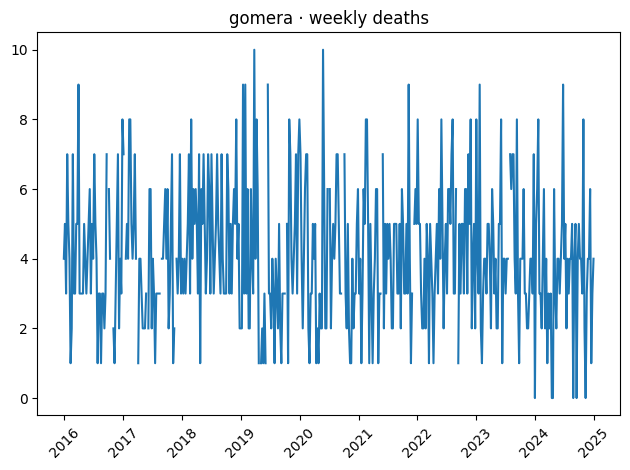

Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\gomera\gom_eda01_weekly_tmax_timeseries.png


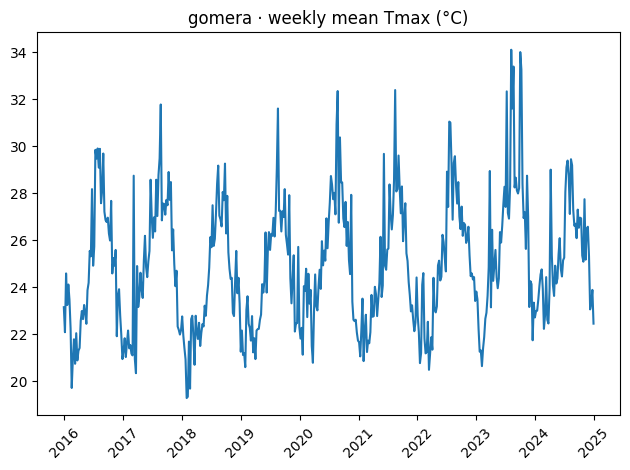

In [6]:
plt.figure()
plt.plot(df["week_start"], df["deaths_week"])
plt.title(f"{ISLAND_NAME} · weekly deaths")
plt.xticks(rotation=45)
plt.tight_layout()
autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_weekly_deaths_timeseries.png")
plt.show()

plt.figure()
plt.plot(df["week_start"], df["tmax_c_mean"])
plt.title(f"{ISLAND_NAME} · weekly mean Tmax (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_weekly_tmax_timeseries.png")
plt.show()


## 5. Temperature and mortality
### 5.1 Absolute temperature vs deaths
Absolute temperature can be heavily confounded by seasonality.


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\gomera\gom_eda01_deaths_vs_absolute_tmax_scatter.png


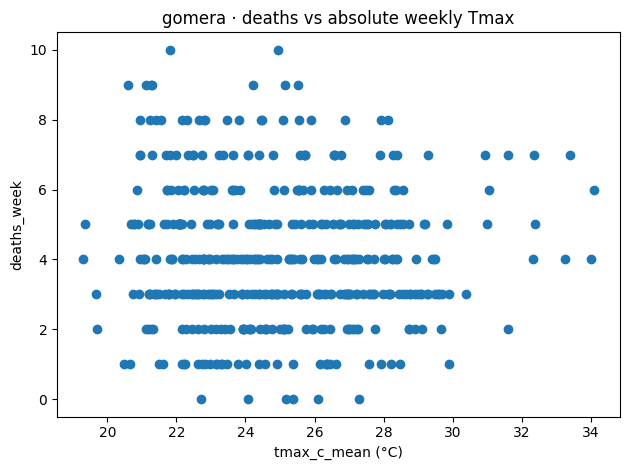

corr(deaths, tmax_c_mean): -0.0437


In [7]:
plt.figure()
plt.scatter(df["tmax_c_mean"], df["deaths_week"])
plt.xlabel("tmax_c_mean (°C)")
plt.ylabel("deaths_week")
plt.title(f"{ISLAND_NAME} · deaths vs absolute weekly Tmax")
plt.tight_layout()
autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_deaths_vs_absolute_tmax_scatter.png")
plt.show()

corr_abs = df[["deaths_week", "tmax_c_mean"]].corr().iloc[0, 1]
print("corr(deaths, tmax_c_mean):", round(float(corr_abs), 4))


##### 5.2 Temperature anomaly vs deaths
Use anomalies (relative temperature) to reduce seasonal confounding.


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\gomera\gom_eda01_deaths_vs_temperature_anomaly_scatter.png


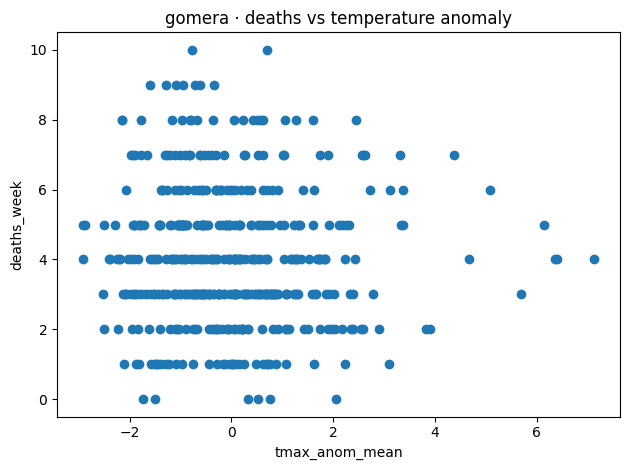

corr(deaths, tmax_anom_mean): -0.0421


In [8]:
anom_col = None
for c in ["tmax_anom_mean_week", "tmax_anom_mean", "tmax_anom_c_mean", "tmax_anom"]:
    if c in df.columns:
        anom_col = c
        break

if anom_col is None:
    print("No anomaly column found in this master. (Skip or create anomalies upstream.)")
else:
    plt.figure()
    plt.scatter(df[anom_col], df["deaths_week"])
    plt.xlabel(anom_col)
    plt.ylabel("deaths_week")
    plt.title(f"{ISLAND_NAME} · deaths vs temperature anomaly")
    plt.tight_layout()
    autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_deaths_vs_temperature_anomaly_scatter.png")
    plt.show()
    corr_anom = df[["deaths_week", anom_col]].corr().iloc[0, 1]
    print(f"corr(deaths, {anom_col}):", round(float(corr_anom), 4))


### 5.3 Extreme heat (p90 / p95)
Compare weeks above an extreme threshold vs the rest.


In [9]:
q90_tmax = df["tmax_c_mean"].quantile(0.90)
q95_tmax = df["tmax_c_mean"].quantile(0.95)

df["heat_p90"] = (df["tmax_c_mean"] >= q90_tmax).astype(int)
df["heat_p95"] = (df["tmax_c_mean"] >= q95_tmax).astype(int)

print(f"Official heat thresholds from tmax_c_mean -> p90={q90_tmax:.2f}, p95={q95_tmax:.2f}")
print(df["heat_p95"].value_counts(dropna=False))

tab_p95 = df.groupby("heat_p95")["deaths_week"].agg(["count", "mean", "median"])
display(tab_p95)

if 0 in tab_p95.index and 1 in tab_p95.index:
    delta_p95 = float(tab_p95.loc[1, "mean"] - tab_p95.loc[0, "mean"])
    print("Δ deaths (heat_p95 vs baseline):", round(delta_p95, 2))

save_table(tab_p95.reset_index(), TAB_DIR, f"heat_p95_deaths_{ISLAND_CODE}.csv", index=False)


Official heat thresholds from tmax_c_mean -> p90=28.47, p95=29.41
heat_p95
0    447
1     24
Name: count, dtype: int64


,count,mean,median
heat_p95,,,
0,430,4.076744,4.0
1,23,4.260870,4.0


Δ deaths (heat_p95 vs baseline): 0.18
Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\heat_p95_deaths_gom.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/gomera/heat_p95_deaths_gom.csv')

## 6. Calima and mortality
Analyze calima intensity proxies vs weekly deaths.

### 6.1 Calima proxy audit
Validate the merged calima proxy coverage and weekly level distribution before using it in downstream comparisons.


,missing,missing_pct
calima_proxy_score_v2,0,0.0
calima_proxy_level_v2,0,0.0


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\calima_proxy_audit_missing_gom.csv


,calima_proxy_level_v2,weeks
0,no_calima,313
1,possible,105
2,intense,28
3,probable,25


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\calima_proxy_level_counts_gom.csv
Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\gomera\gom_eda01_calima_proxy_level_counts.png


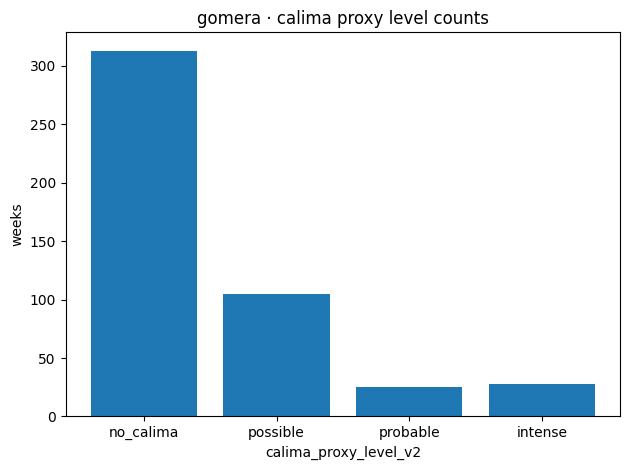

CAP yellow alignment with proxy (probable+intense among CAP yellow): 0.7647


In [10]:
proxy_cols = ["calima_proxy_score_v2", "calima_proxy_level_v2"]
have_proxy = all(c in df.columns for c in proxy_cols)

if have_proxy:
    proxy_na = df[proxy_cols].isna().sum().rename("missing").to_frame()
    proxy_na["missing_pct"] = (proxy_na["missing"] / len(df)).round(4)
    display(proxy_na)
    save_table(proxy_na.reset_index().rename(columns={"index": "column"}), TAB_DIR, f"calima_proxy_audit_missing_{ISLAND_CODE}.csv", index=False)

    proxy_counts = (
        df["calima_proxy_level_v2"]
        .value_counts(dropna=False)
        .rename_axis("calima_proxy_level_v2")
        .reset_index(name="weeks")
    )
    display(proxy_counts)
    save_table(proxy_counts, TAB_DIR, f"calima_proxy_level_counts_{ISLAND_CODE}.csv", index=False)

    plot_counts = df["calima_proxy_level_v2"].dropna().value_counts()
    if not plot_counts.empty:
        desired_order = ["no_calima", "possible", "probable", "intense"]
        plot_counts = plot_counts.reindex([x for x in desired_order if x in plot_counts.index])

        plt.figure()
        plt.bar(plot_counts.index.astype(str), plot_counts.values)
        plt.title(f"{ISLAND_NAME} · calima proxy level counts")
        plt.xlabel("calima_proxy_level_v2")
        plt.ylabel("weeks")
        plt.tight_layout()
        autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_calima_proxy_level_counts.png")
        plt.show()

    if {"cap_dust_yellow_plus_week", "calima_proxy_level_v2"}.issubset(df.columns):
        tmp = df.copy()
        tmp["proxy_ge_probable"] = tmp["calima_proxy_level_v2"].isin(["probable", "intense"])
        cap_yellow = tmp["cap_dust_yellow_plus_week"] == 1
        alignment = tmp.loc[cap_yellow, "proxy_ge_probable"].mean()
        print("CAP yellow alignment with proxy (probable+intense among CAP yellow):", round(float(alignment), 4))
else:
    print("No calima proxy level column found in this master.")


### 6.2 Calima levels and deaths
Compare weekly deaths across calima proxy levels (or DAI fallback if proxy columns are unavailable).


In [11]:
if "calima_proxy_level_v2" in df.columns:
    cal = df.groupby("calima_proxy_level_v2")["deaths_week"].agg(["count", "mean", "median"])
    level_order = ["no_calima", "possible", "probable", "intense"]
    cal = cal.reindex([x for x in level_order if x in cal.index])
    display(cal)
    save_table(cal.reset_index(), TAB_DIR, f"calima_proxy_level_v2_deaths_{ISLAND_CODE}.csv", index=False)
else:
    print("No calima_proxy_level_v2. Using calima_dai_flag if available...")
    if "calima_dai_flag" in df.columns:
        cal = df.groupby("calima_dai_flag")["deaths_week"].agg(["count", "mean", "median"]).sort_index()
        display(cal)
        save_table(cal.reset_index(), TAB_DIR, f"calima_dai_flag_deaths_{ISLAND_CODE}.csv", index=False)


,count,mean,median
calima_proxy_level_v2,,,
no_calima,300,4.023333,4.0
possible,101,4.247525,4.0
probable,24,3.875000,4.0
intense,28,4.357143,4.0


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\calima_proxy_level_v2_deaths_gom.csv


## 7. Interaction: extreme heat × calima
A simple 2×2 cross-tab.


In [12]:
tmp = df.copy()

if "calima_proxy_level_v2" in tmp.columns:
    tmp["calima_intense"] = (tmp["calima_proxy_level_v2"] == "intense").astype(int)
else:
    tmp["calima_intense"] = 0

# 2x2 count table to verify whether joint exposure exists
ct = pd.crosstab(tmp["heat_p95"], tmp["calima_intense"], dropna=False)
display(ct)

joint_n = ((tmp["heat_p95"] == 1) & (tmp["calima_intense"] == 1)).sum()
print(f"Weeks with heat_p95=1 and calima_intense=1: {joint_n}")

# Descriptive mortality summary by joint exposure group
inter = (
    tmp.groupby(["heat_p95", "calima_intense"])["deaths_week"]
       .agg(["count", "mean", "median"])
       .reindex(pd.MultiIndex.from_product([[0, 1], [0, 1]],
                                           names=["heat_p95", "calima_intense"]))
)

inter["count"] = inter["count"].fillna(0).astype(int)

display(inter)

save_table(ct.reset_index(), TAB_DIR, f"interaction_counts_heat_p95_x_calima_intense_{ISLAND_CODE}.csv", index=False)
save_table(inter.reset_index(), TAB_DIR, f"interaction_heat_p95_x_calima_intense_{ISLAND_CODE}.csv", index=False)


calima_intense,0,1
heat_p95,,
0,420,27
1,23,1


Weeks with heat_p95=1 and calima_intense=1: 1


count      mean  median
heat_p95 calima_intense                         
0        0                 403  4.064516     4.0
         1                  27  4.259259     4.0
1        0                  22  4.136364     4.0
         1                   1  7.000000     7.0

Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\interaction_counts_heat_p95_x_calima_intense_gom.csv
Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\gomera\interaction_heat_p95_x_calima_intense_gom.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/gomera/interaction_heat_p95_x_calima_intense_gom.csv')

### Key numbers to report
- Δ deaths (heat p95 vs baseline): **0.18**
- Δ deaths (calima intense vs no_calima): **0.33 deaths/weeks**
- Proxy coverage / missingness: **0.00%**
- CAP yellow alignment with proxy: **0.7647**
- corr(deaths, tmax_c_mean): **-0.0437**
- corr(deaths, Tmax anomaly): **-0.0421**


Overall, the Gomera audit/EDA passes the basic quality checks: week_start parses correctly, no duplicate weekly keys were found, and no negative death counts were detected. Core weekly mortality coverage is reasonably strong, although deaths_week is still missing in 18 weeks (3.8%). Temperature variables are complete, while CAP heat/dust coverage is only available for part of the series (342 of 471 weeks, about 72.6%), and DAI/calima-related coverage is more limited. PM2.5 coverage is also too sparse to support strong interpretation.

Substantively, the signal in Gomera appears weak and should be interpreted with caution. The observed differences are small: mean weekly deaths are only slightly higher in heat_p95 weeks than in baseline weeks (+0.18), and slightly higher in intense calima weeks than in no_calima weeks (+0.33). Correlations between deaths and both absolute Tmax and Tmax anomaly are also near zero. In addition, the joint exposure of extreme heat and intense calima is almost absent in the series, which prevents any meaningful interaction assessment.

This weak signal should not be overinterpreted. Gomera has a much smaller population than islands such as Tenerife or Gran Canaria, and weekly death counts are correspondingly low. That means random week-to-week variation can have a proportionally larger effect, making the island less suitable for strong inferential claims. In practice, Gomera should be treated mainly as an orientative case study: useful for descriptive comparison across islands, but not robust enough on its own to support firm conclusions about heat-, calima-, or pollution-related mortality patterns.

### 🔎 Pending Task – Extended Aggregation Analysis
**“Limitations & Next Analytical Step”**

Given the small population size of Gomera and the resulting high week-to-week variability in mortality, the current weekly analysis may lack sufficient statistical power to detect stable heat or calima signals.

As a next step, it is recommended to complement the weekly EDA with longer aggregation windows to assess whether broader patterns emerge. This should be treated as an extension of the current EDA, not a replacement.

Planned checks:

* Monthly aggregation of deaths, temperature, and calima indicators
* Rolling averages (e.g., 4-week and 8-week windows)
* Accumulated exposure metrics (e.g., number of heat_p95 or intense calima weeks over the previous 4–8 weeks)

Objective:
To evaluate whether the weak signals observed at weekly resolution are due to noise (low population / low counts) or reflect a genuinely weak relationship between climate variables and mortality in Gomera.

---

**ESPAÑOL**

Dado el pequeño tamaño poblacional de La Gomera y la alta variabilidad semanal en la mortalidad, el análisis semanal actual puede no tener suficiente potencia estadística para detectar señales estables de calor o calima.

Como siguiente paso, se recomienda complementar el EDA semanal con agregaciones en ventanas temporales más largas, para evaluar si emergen patrones más robustos. Esto debe entenderse como una extensión del análisis actual, no como un sustituto.

Comprobaciones planificadas:

* Agregación mensual de muertes, temperatura e indicadores de calima
* Medias móviles (por ejemplo, ventanas de 4 y 8 semanas)
* Métricas de exposición acumulada (por ejemplo, número de semanas con heat_p95 o calima intensa en las últimas 4–8 semanas)

Objetivo:
Evaluar si las señales débiles observadas a nivel semanal se deben al ruido (población pequeña / pocos eventos) o reflejan realmente una relación débil entre variables climáticas y mortalidad en La Gomera.